Ahora vamos con segmentación de los latidos

In [1]:
import os
import wfdb
import pandas as pd
import numpy as np

Para la segmentación de latidos usamos la base de datos QTDB 

In [2]:
data_folder = "data"
qtdb_dir = os.path.join(data_folder, "qtdb_data")
os.makedirs(qtdb_dir, exist_ok=True)

if not os.listdir(qtdb_dir):
    print("Downloading the QTDB Database...")
    wfdb.dl_database('qtdb', dl_dir=qtdb_dir)
    print("Download completed.")
else: 
    print("Database already exists, skipping download.")

Database already exists, skipping download.


trabajamos con esta base de datos a 250hz teniendo 500 muestras por latido

In [3]:
record = wfdb.rdrecord("data/qtdb_data/sel820")
print("Canales:", record.sig_name)
print("Frecuencia de muestreo:", record.fs)
print("Forma de la señal:", record.p_signal.shape)

# .q1c o .qt1 — anotaciones del anotador 1
ann = wfdb.rdann('data/qtdb_data/sel820', 'q1c')

print("Símbolos:", ann.symbol)
print("Muestras:", ann.sample)
print("Aux notes:", ann.aux_note)  # ← aquí está la clave

records = [f.replace('.hea', '') for f in os.listdir('data/qtdb_data') if f.endswith('.hea')]
print(records)

Canales: ['ECG1', 'ECG2']
Frecuencia de muestreo: 250
Forma de la señal: (224999, 2)
Símbolos: ['(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N', ')', 't', ')', '(', 'p', ')', '(', 'N',

In [4]:
def wave_annotations(ann, signal_length):
    labels = np.zeros(signal_length)
    i = 0
    while i < len(ann.symbol):
        
        if ann.symbol[i] == '(':
            begin = ann.sample[i]

            if i + 1 < len(ann.symbol):
                next_symbol = ann.symbol[i + 1]

                if next_symbol == 'p':
                    wave_class = 1
                elif next_symbol == 'N':
                    wave_class = 2
                elif next_symbol == 't':
                    wave_class = 3
                else:
                    wave_class = 0

                j = i + 1
                while j < len(ann.symbol) and ann.symbol[j] != ')':
                    j += 1

                if ann.symbol[j] == ')':
                    end = ann.sample[j]
                    labels[begin:end] = wave_class
                i = j

        elif ann.symbol[i] == 't':
            begin = ann.sample[i]
            j = i + 1
            if j < len(ann.symbol) and ann.symbol[j] == ')':
                end = ann.sample[j]
                labels[begin:end] = 3  
            i = j

        i += 1

    return labels

labels = wave_annotations(ann, len(record.p_signal))
print(labels)

[0. 0. 0. ... 0. 0. 0.]


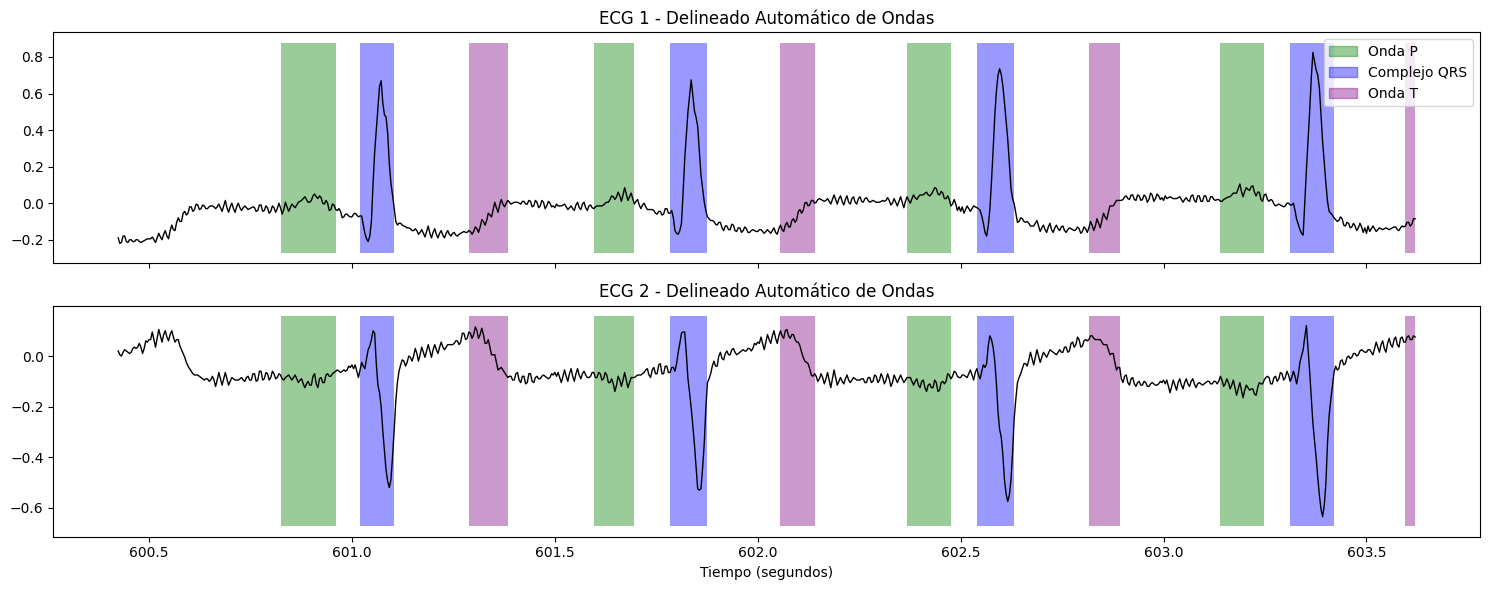

Clase 1 (P): 117
Clase 2 (QRS): 98
Clase 3 (T): 74


In [5]:
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. BUSCADOR AUTOMÁTICO DEL PRIMER LATIDO ANOTADO
# Buscamos dónde hay algún valor que no sea 0
indices_anotados = np.where(labels != 0)[0]
primer_indice_util = indices_anotados[0]

# Centramos nuestra ventana alrededor de ese latido 
# (ej: 200 puntos antes y 600 después para ver bien la onda)
inicio = primer_indice_util - 100
fin = primer_indice_util + 700

# 2. PREPARAR EL EJE DE TIEMPO
# (Asumimos que fs está definido, en QTDB suele ser 250)
tiempo = np.arange(inicio, fin) / 250

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 6), sharex=True)

ax1.plot(tiempo, record.p_signal[inicio:fin, 0], color='black', linewidth=1)
ax2.plot(tiempo, record.p_signal[inicio:fin, 1], color='black', linewidth=1)

# Forzamos que matplotlib calcule los límites reales ANTES de fill_between
fig.canvas.draw()

ymin1, ymax1 = ax1.get_ylim()
ymin2, ymax2 = ax2.get_ylim()

colores_clases = {
    1: ('green',  'Onda P'),
    2: ('blue',   'Complejo QRS'),
    3: ('purple', 'Onda T')
}

for clase, (color, nombre) in colores_clases.items():
    mascara = (labels[inicio:fin] == clase)
    ax1.fill_between(tiempo, ymin1, ymax1, where=mascara, facecolor=color, alpha=0.4)
    ax2.fill_between(tiempo, ymin2, ymax2, where=mascara, facecolor=color, alpha=0.4)

ax1.set_title('ECG 1 - Delineado Automático de Ondas')
ax2.set_title('ECG 2 - Delineado Automático de Ondas')
ax2.set_xlabel('Tiempo (segundos)')

leyenda = [Patch(color=color, alpha=0.4, label=nombre) 
           for clase, (color, nombre) in colores_clases.items()]
ax1.legend(handles=leyenda, loc='upper right')

plt.tight_layout()
plt.show()
ventana = labels[inicio:fin]
print("Clase 1 (P):", np.sum(ventana == 1))
print("Clase 2 (QRS):", np.sum(ventana == 2))
print("Clase 3 (T):", np.sum(ventana == 3))

In [6]:
def create_window(signal, label, window_size=500, step=250, ratio_silencio=0.10):
    X = []
    y = []

    for i in range(0, len(signal) - window_size + 1, step):
        x_window = signal[i : i + window_size]
        y_window = label[i : i + window_size]

        has_wave = np.any(y_window > 0)

        if has_wave: # onda P, QRS o T
            X.append(x_window)
            y.append(y_window)
        else: # es silencio (cogemos un porcentaje)
            if np.random.random() < ratio_silencio:
                X.append(x_window)
                y.append(y_window)

    return np.array(X), np.array(y)

In [7]:
from scipy.signal import butter, filtfilt

def filtrar_ecg(signal, fs=250):
    """
    Aplica un filtro Butterworth pasa-banda (0.5Hz - 45Hz) para limpiar la señal.
    """
    nyq = 0.5 * fs

    low = 0.5 / nyq
    high = 45.0 / nyq
    
    b, a = butter(4, [low, high], btype='band')
    
    signal_filtrada = np.zeros_like(signal)
    for ch in range(signal.shape[1]):
        signal_filtrada[:, ch] = filtfilt(b, a, signal[:, ch])
        
    return signal_filtrada

In [8]:
def process_patients(patients_list):
    dir = "data/qtdb_data/"
    X, y = [], []

    for patient in patients_list:
        record = wfdb.rdrecord(dir + patient)
        fs = record.fs
        ann = wfdb.rdann(dir + patient, "q1c")
        signal_length = len(record.p_signal)

        labels = wave_annotations(ann, signal_length)
        signal_pura = filtrar_ecg(record.p_signal, fs=fs)
        
        X_w, y_w = create_window(signal_pura, labels)

        X.append(X_w)
        y.append(y_w)

    X = np.concatenate(X, axis=0)
    y = np.concatenate(y, axis=0)
    
    indices = np.arange(len(X))
    np.random.shuffle(indices)
    
    return X[indices], y[indices]

In [ ]:
patients_train = [
    'sel100', 'sel102', 'sel103', 'sel104', 'sel114',
    'sel116', 'sel117', 'sel123', 'sel213', 'sel221',
    'sel223', 'sel230', 'sel301', 'sel302', 'sel306',
    'sel307', 'sel803', 'sel808', 'sel811', 'sel820',
    'sel821', 'sel840', 'sel847', 'sel853', 'sel871',
    'sel872', 'sel16265', 'sel16272', 'sel16273', 'sel16420',
    'sel16483', 'sel16539', 'sel16773', 'sel16786', 'sele0104',
    'sele0106', 'sele0107', 'sele0110', 'sele0111', 'sele0112',
    'sele0114', 'sele0116', 'sele0121', 'sele0122', 'sele0124',
    'sele0126', 'sele0129', 'sele0133', 'sele0136', 'sele0166',
    'sele0170', 'sele0203', 'sele0210', 'sele0211', 'sele0303',
    'sele0405', 'sele0406', 'sele0409', 'sele0411', 'sele0509',
    'sele0603', 'sel30', 'sel31', 'sel32', 'sel33', 
    'sel34', 'sel35', 'sel36', 'sel37', 'sel38',
    'sel39', 'sel40', 'sel41', 'sel42', 'sel43',
    'sel44', 'sel45', 'sel46', 'sel47', 'sel48',
    'sel14046', 'sel14157'
]

patients_test = [
    'sel231', 'sel232', 'sel233', 'sel308', 'sel310',
    'sel873', 'sel883', 'sel891', 'sel16795', 'sel17453', 
    'sele0604', 'sele0606', 'sele0607', 'sele0609', 'sele0612',
    'sele0704', 'sel49', 'sel50', 'sel51', 'sel52',
    'sel17152', 'sel14172', 'sel15814'
]

data_dir = "data"
npy_dir = os.path.join(data_dir, "npy_data_qtdb")

if not os.path.exists(npy_dir):
    print("Creating npy_dir folder")
    os.makedirs(npy_dir)
    X_train, y_train = process_patients(patients_train)
    X_test, y_test = process_patients(patients_test)
    np.save(os.path.join(npy_dir, "X_train_QT.npy"), X_train)
    np.save(os.path.join(npy_dir, "y_train_QT.npy"), y_train)
    np.save(os.path.join(npy_dir, "X_test_QT.npy"),  X_test)
    np.save(os.path.join(npy_dir, "y_test_QT.npy"),  y_test)
    print("Data saved.")
else:
    print("Data already exists, loading from disk...")
    X_train = np.load(os.path.join(npy_dir, "X_train_QT.npy"))
    y_train = np.load(os.path.join(npy_dir, "y_train_QT.npy"))
    X_test  = np.load(os.path.join(npy_dir, "X_test_QT.npy"))
    y_test  = np.load(os.path.join(npy_dir, "y_test_QT.npy"))

Data already exists, loading from disk...


In [ ]:
def normalize_windows(X):
    '''
    usamos Z-score
    '''
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True) + 1e-8
    return (X - mean) / std

X_train_norm = normalize_windows(X_train)
X_test_norm = normalize_windows(X_test)

In [11]:
'''
Esto cuando se pase a .py se puede quitar ya que se importará de forma directa (la función normalize)
'''
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, RepeatVector, TimeDistributed, UpSampling1D, Conv1DTranspose, Input, Bidirectional, concatenate, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

'''
Modelo secuencial no es optimo ya que el kernel size es muy pequeño
model = Sequential()
model.add(Input(shape=(500, 2)))
model.add(Conv1D(filters=32, kernel_size=11, padding='same', activation='relu'))
model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Bidirectional(LSTM(32, return_sequences=True)))
model.add(TimeDistributed(Dense(32, activation='relu')))
model.add(TimeDistributed(Dense(4, activation='softmax'))) 
'''
#valores anteriores de las capas del lstm eran la mitad, 64 y 32
input_layer = Input(shape = (500, 2))
conv_low = Conv1D(filters = 16, kernel_size = 5, padding = "same", activation = "relu")(input_layer)
conv_mid = Conv1D(filters = 16, kernel_size = 15, padding = "same", activation = "relu")(input_layer)
conv_hi = Conv1D(filters = 16, kernel_size= 40, padding = "same", activation = "relu")(input_layer)
conv_total = concatenate([conv_low, conv_mid, conv_hi])
normalization_layer = BatchNormalization()(conv_total)
lstm_layer = Bidirectional(LSTM(128, return_sequences = True))(normalization_layer)
dropout_layer1 = Dropout(0.3)(lstm_layer)
lstm_layer2 = Bidirectional(LSTM(64, return_sequences = True))(dropout_layer1)
dropout_layer2 = Dropout(0.3)(lstm_layer2)
dense_layer = TimeDistributed(Dense(32, activation = "relu"))(dropout_layer2)
output_layer = TimeDistributed(Dense(4, activation = "softmax"))(dense_layer)

model = Model(inputs = input_layer, outputs = output_layer)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 500, 2)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 500, 16)   │        176 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 500, 16)   │        496 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 500, 16)   │      1,296 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 500, 48)   │          0 │ conv1d[0][0],     │
│ (Concatenate)       │                   │            │ conv1d_1[0][0],   │
│                     │                   │            │ conv1d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 500, 48)   │        192 │ concatenate[0][0] │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 500, 256)  │    181,248 │ batch_normalizat… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 500, 256)  │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 500, 128)  │    164,352 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 500, 128)  │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 500, 32)   │      4,128 │ dropout_1[0][0]   │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed_1  │ (None, 500, 4)    │        132 │ time_distributed… │
│ (TimeDistributed)   │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 352,020 (1.34 MB)

 Trainable params: 351,924 (1.34 MB)

 Non-trainable params: 96 (384.00 B)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

TRAIN_MODEL = True  # cambiar a True para reentrenar

weights_map = {0: 0.1, 1: 15.0, 2: 15.0, 3: 15.0}

# Creamos una matriz vacía exactamente del mismo tamaño que y_train, pero en 2D (sin el canal final)
# Si y_train es (ventanas, 500, 1), sample_weights será (ventanas, 500)
sample_weights = np.zeros(shape=(y_train.shape[0], y_train.shape[1]), dtype=np.float32)

# Rellenamos la matriz. Si en un punto temporal y_train dice "2", le ponemos un peso de "8.0"
for clase, peso in weights_map.items():
    # Asumimos que y_train tiene shape (N, 500, 1), usamos [:, :, 0] para quitar la última dimensión
    mascara = (y_train == clase)
    sample_weights[mascara] = peso

model.compile(
    optimizer=Adam(learning_rate=0.0001, clipnorm = 1.0), #lr demasiado alto, bajar a la mitad o probar con menos 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=15, 
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', 
    factor=0.5,     
    patience=6,      
    min_lr=1e-6,
    verbose=1
)

model_save = ModelCheckpoint(
    filepath = "labeling_v1_dropout_doubled_neurons.keras",
    save_best_only = True,
    verbose = 1,
    monitor = "val_loss"
)

print("Starting training...")
history = model.fit(
    X_train_norm, 
    y_train,
    epochs=50, 
    batch_size=32,
    validation_data=(X_test_norm, y_test),
    sample_weight=sample_weights, 
    callbacks=[early_stop, reduce_lr, model_save]
)

Starting training...
Epoch 1/50
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4525 - loss: 0.1801
Epoch 1: val_loss improved from None to 0.89169, saving model to labeling_v1_dropout_doubled_neurons.keras

Epoch 1: finished saving model to labeling_v1_dropout_doubled_neurons.keras
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 4422s 2s/step - accuracy: 0.4605 - loss: 0.1690 - val_accuracy: 0.4436 - val_loss: 0.8917 - learning_rate: 1.0000e-04
Epoch 2/50
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4735 - loss: 0.1560
Epoch 2: val_loss improved from 0.89169 to 0.67854, saving model to labeling_v1_dropout_doubled_neurons.keras

Epoch 2: finished saving model to labeling_v1_dropout_doubled_neurons.keras
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 4322s 2s/step - accuracy: 0.4865 - loss: 0.1516 - val_accuracy: 0.5540 - val_loss: 0.6785 - learning_rate: 1.0000e-04
Epoch 3/50
2303/2303 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5027 - loss: 0.1457
Epoch 3: val_loss did not improve from 0.67854
23

1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


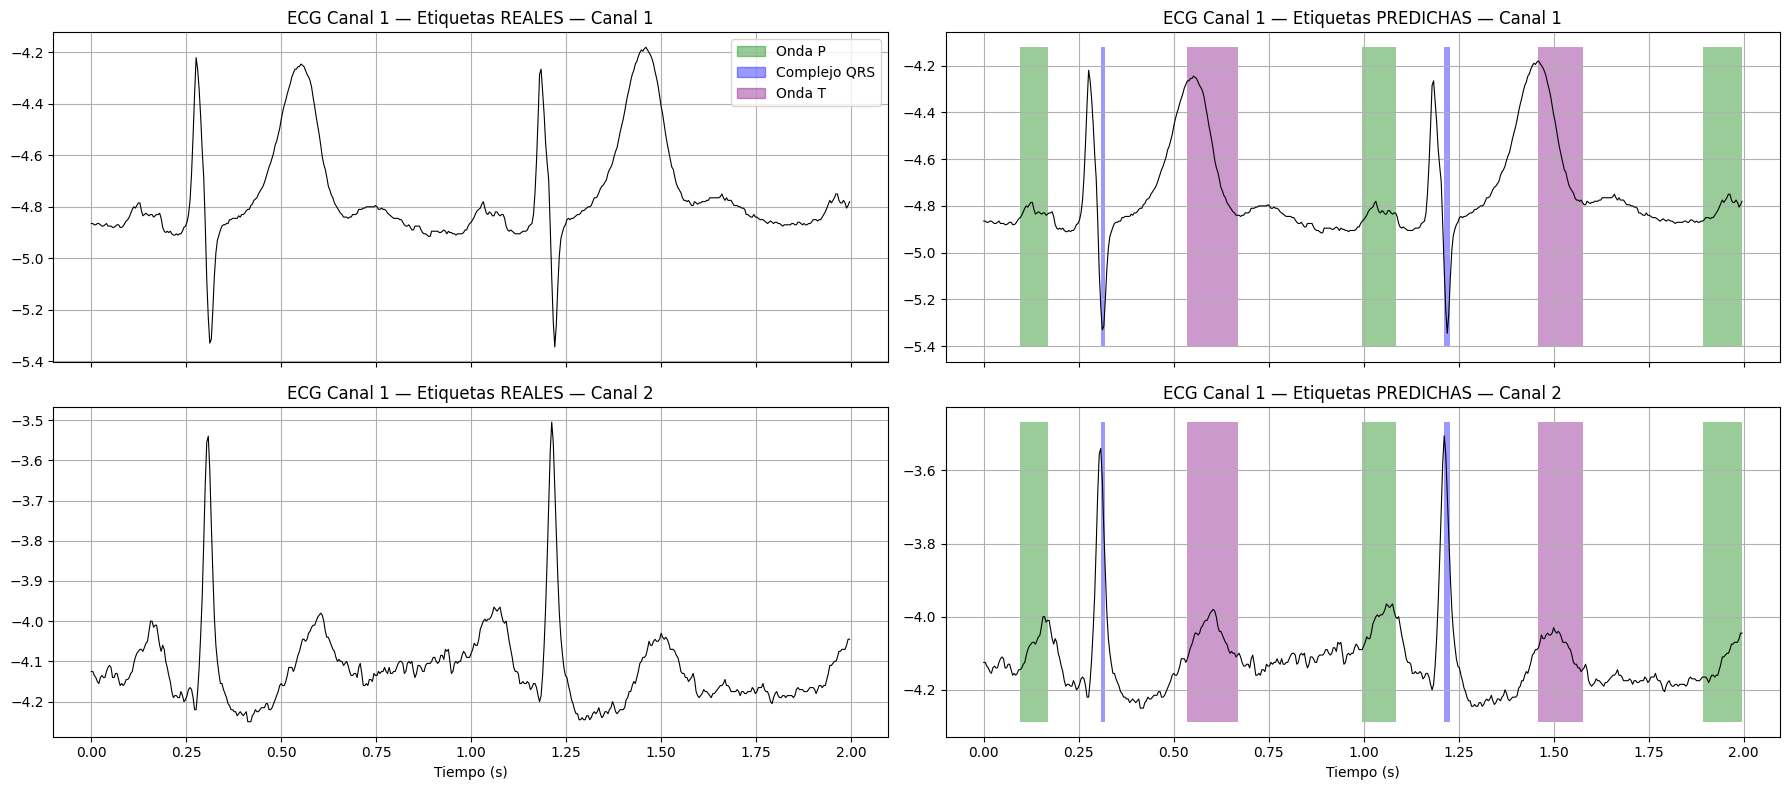

Accuracy en esta ventana: 0.7160
Clase 1 (P)  — Real:   0 | Pred:  69
Clase 2 (QRS)— Real:   0 | Pred:   9
Clase 3 (T)  — Real:   0 | Pred:  64
Clase 0 (BL) — Real: 500 | Pred: 358


In [25]:
from tensorflow.keras.models import load_model

model = load_model("labeling_v1_dropout_doubled_neurons.keras", compile=False)

indice = 9000

x_ventana = X_test_norm[indice:indice+1]  # shape (1, 500, 2)

# Predecimos — salida shape (1, 500, 4) con probabilidades por clase
pred = model.predict(x_ventana)

# Cogemos la clase con   mayor probabilidad para cada muestra
pred_clases = np.argmax(pred[0], axis=-1)  # shape (500,)
y_real      = y_test[indice, :]         # shape (500,) — quitamos la dimensión extra

tiempo = np.arange(500) / 250  # eje de tiempo en segundos

colores_clases = {
    1: ('green',  'Onda P'),
    2: ('blue',   'Complejo QRS'),
    3: ('purple', 'Onda T')
}

fig, axes = plt.subplots(2, 2, figsize=(18, 8), sharex=True)

titulos = [
    ('ECG Canal 1 — Etiquetas REALES',     y_real,      axes[0, 0], axes[1, 0]),
    ('ECG Canal 1 — Etiquetas PREDICHAS',  pred_clases, axes[0, 1], axes[1, 1]),
]

for titulo, etiquetas, ax1, ax2 in titulos:
    ax1.plot(tiempo, X_test[indice][:, 0], color='black', linewidth=0.8)
    ax2.plot(tiempo, X_test[indice][:, 1], color='black', linewidth=0.8)

    fig.canvas.draw()
    ymin1, ymax1 = ax1.get_ylim()
    ymin2, ymax2 = ax2.get_ylim()

    for clase, (color, nombre) in colores_clases.items():
        mascara = (etiquetas == clase)
        ax1.fill_between(tiempo, ymin1, ymax1, where=mascara, facecolor=color, alpha=0.4)
        ax2.fill_between(tiempo, ymin2, ymax2, where=mascara, facecolor=color, alpha=0.4)

    ax1.set_title(f'{titulo} — Canal 1')
    ax2.set_title(f'{titulo} — Canal 2')
    ax1.grid(True)
    ax2.grid(True)

from matplotlib.patches import Patch
leyenda = [Patch(color=c, alpha=0.4, label=n) for _, (c, n) in colores_clases.items()]
axes[0, 0].legend(handles=leyenda)

axes[1, 0].set_xlabel('Tiempo (s)')
axes[1, 1].set_xlabel('Tiempo (s)')

plt.tight_layout()
plt.show()

# Métricas rápidas
print(f"Accuracy en esta ventana: {np.mean(pred_clases == y_real):.4f}")
print(f"Clase 1 (P)  — Real: {np.sum(y_real==1):3d} | Pred: {np.sum(pred_clases==1):3d}")
print(f"Clase 2 (QRS)— Real: {np.sum(y_real==2):3d} | Pred: {np.sum(pred_clases==2):3d}")
print(f"Clase 3 (T)  — Real: {np.sum(y_real==3):3d} | Pred: {np.sum(pred_clases==3):3d}")
print(f"Clase 0 (BL) — Real: {np.sum(y_real==0):3d} | Pred: {np.sum(pred_clases==0):3d}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step


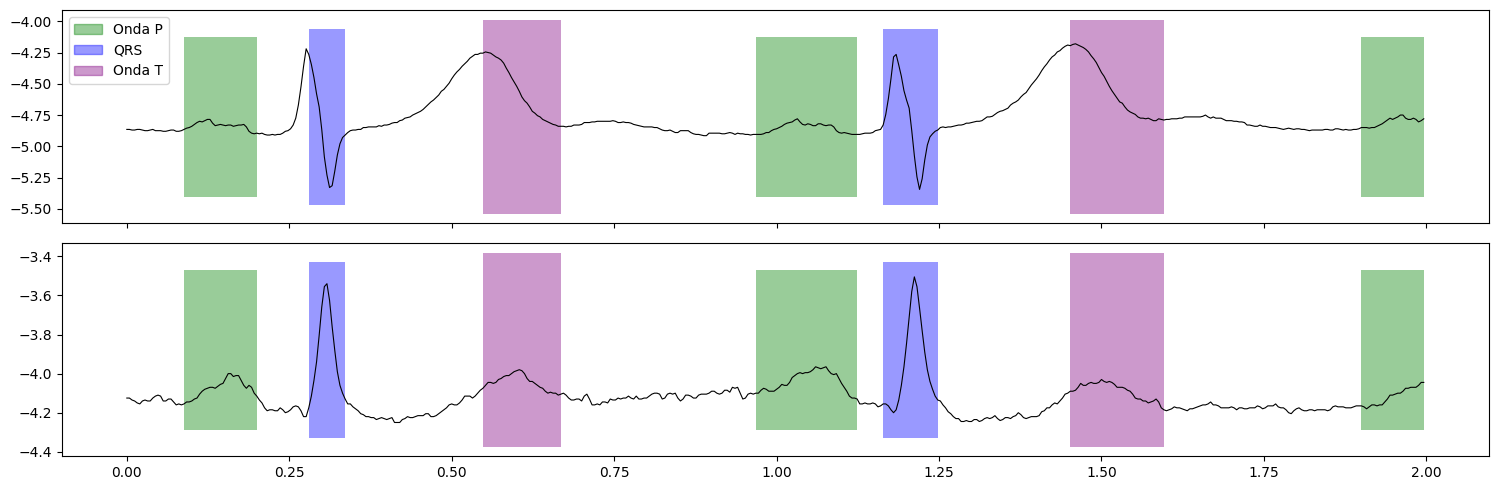

In [23]:
# Coge una ventana "sin anotaciones" y grafícala
indice_sin_ann = 9000  # una de las que dio 0 en todo

x_ventana = X_test_norm[indice_sin_ann:indice_sin_ann+1]
pred = model.predict(x_ventana)
pred_clases = np.argmax(pred[0], axis=-1)

tiempo = np.arange(500) / 250

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 5), sharex=True)
ax1.plot(tiempo, X_test[indice_sin_ann][:, 0], color='black', linewidth=0.8)
ax2.plot(tiempo, X_test[indice_sin_ann][:, 1], color='black', linewidth=0.8)

fig.canvas.draw()
colores = {1: ('green', 'Onda P'), 2: ('blue', 'QRS'), 3: ('purple', 'Onda T')}

for clase, (color, nombre) in colores.items():
    mascara = (pred_clases == clase)
    ax1.fill_between(tiempo, *ax1.get_ylim(), where=mascara, facecolor=color, alpha=0.4)
    ax2.fill_between(tiempo, *ax2.get_ylim(), where=mascara, facecolor=color, alpha=0.4)

from matplotlib.patches import Patch
ax1.legend(handles=[Patch(color=c, alpha=0.4, label=n) for _, (c, n) in colores.items()])
plt.tight_layout()
plt.show()